In [22]:
import numpy as np
import torch

from frame import Frame
from lidar.bev_net import PointPillars
from lidar.pfn import PFNLayer
from lidar.pillarization import Pillarization
from lidar.train import detection_loss


In [23]:
DEFAULT_PATH_IMG = '../data/data_object_image_2/training/image_2/'
DEFAULT_PATH_LIDAR = '../data/data_object_velodyne/training/velodyne/'
DEFAULT_PATH_CALIB = '../data/data_object_calib/training/calib/'
DEFAULT_PATH_LABEL = '../data/data_object_label_2/training/label_2/'

In [24]:
frame = Frame('000006', DEFAULT_PATH_IMG, DEFAULT_PATH_LIDAR, DEFAULT_PATH_CALIB, DEFAULT_PATH_LABEL)
frame.load_lidar()

raw_lidar = frame.raw_lidar
print(f'Raw LIDAR Points: {raw_lidar.shape[0]}')

Raw LIDAR Points: 110089


In [25]:
x_min, x_max = 0.0, 69.12
y_min, y_max = -39.68, 39.68
z_min, z_max = -3.0, 1.0

delta_x, delta_y = 0.16, 0.16

pillarize = Pillarization(x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, z_min=z_min, z_max=z_max, delta_x=delta_x, delta_y=delta_y)

print(f'No. of pillars (N_x, N_y): {(pillarize._N_x, pillarize._N_y)}')

No. of pillars (N_x, N_y): (432, 496)


In [26]:
cropped_lidar = pillarize.crop(raw_lidar)
print(f'Cropped LIDAR Points: {cropped_lidar.shape[0]}')

Cropped LIDAR Points: 53215


In [27]:
indexed_lidar = pillarize.assign_pillars(cropped_lidar)

In [28]:
pillars = pillarize.create_pillars(indexed_lidar, Np_max=32)
print(pillars.shape)

(496, 432, 32, 4)


In [29]:
non_empty_mask = np.any(pillars != 0, axis=(2, 3))
print(f'No. of non-empty pillars: P = {non_empty_mask.sum()}')

# keep only non-empty pillars + save their coordinates
non_empty = pillars[non_empty_mask]
non_empty_coords = np.argwhere(non_empty_mask)

No. of non-empty pillars: P = 11946


In [30]:
aug_pillars = pillarize.augment_pillars(pillars=non_empty,
                                        pillar_coords=non_empty_coords)

print(f'Augmented pillars tensor: {aug_pillars.shape}')

Augmented pillars tensor: (11946, 32, 9)


In [31]:
# creating pillar tensor
pillars_tensor = torch.from_numpy(aug_pillars).to(dtype=torch.float32)

In [32]:
pfn = PFNLayer(in_channels=9, out_channels=64)
features = pfn(pillars_tensor)

print(f'Pillars feature tensor: {features.shape}')

Pillars feature tensor: torch.Size([11946, 64])


__Plotting Individual PFN Channel Outputs__

In [33]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

bev = pillarize.scatter_bev(pillar_features=features, 
                            pillar_coords=non_empty_coords)

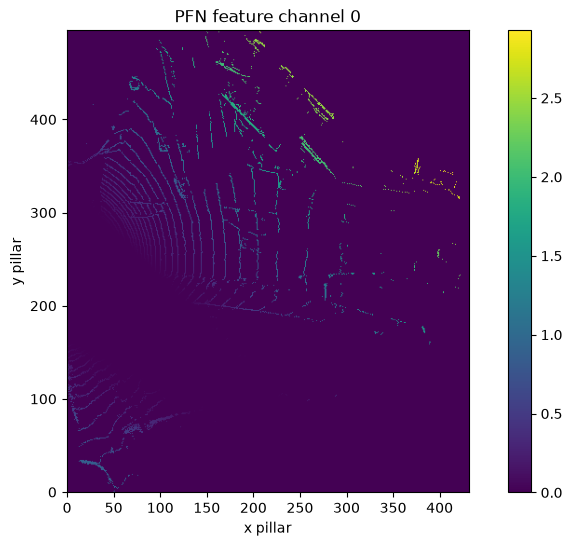

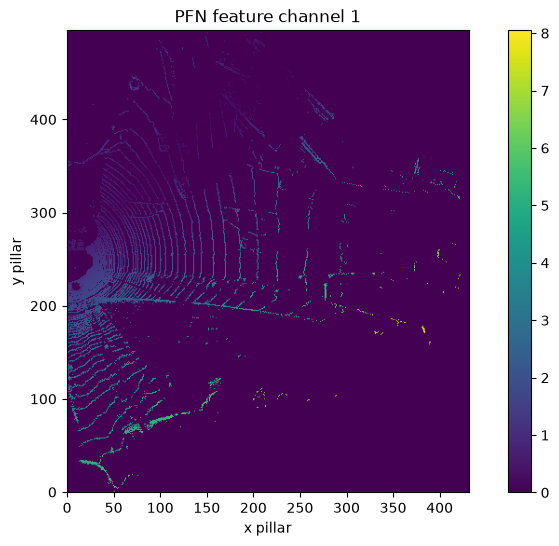

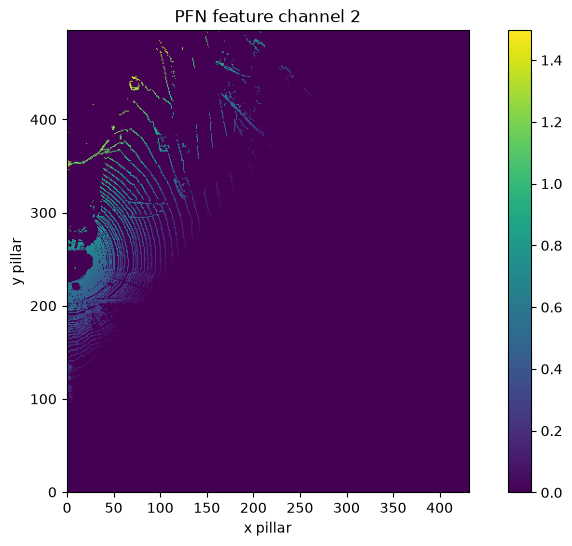

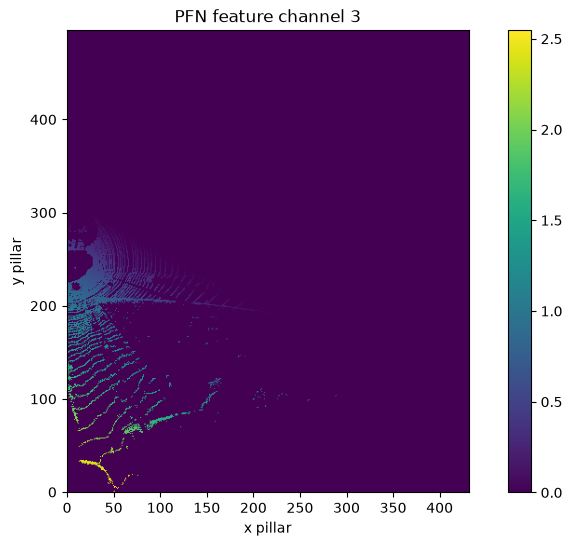

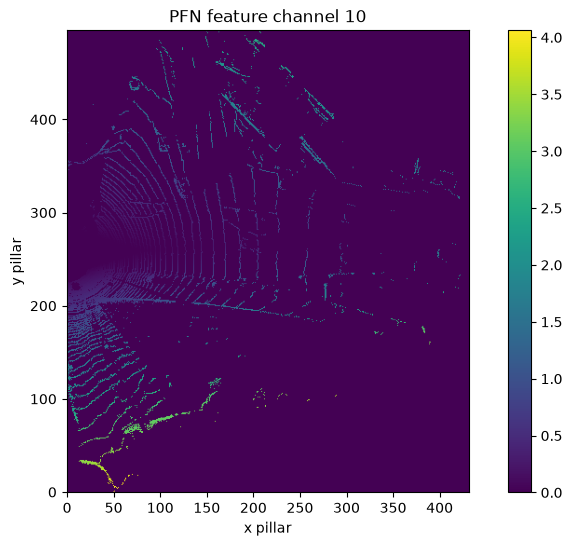

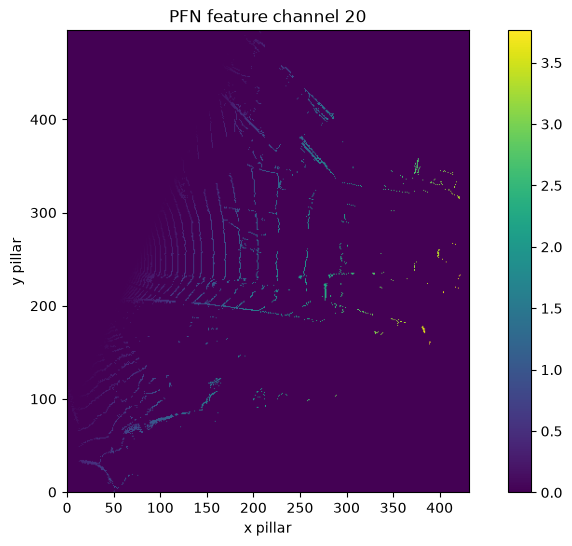

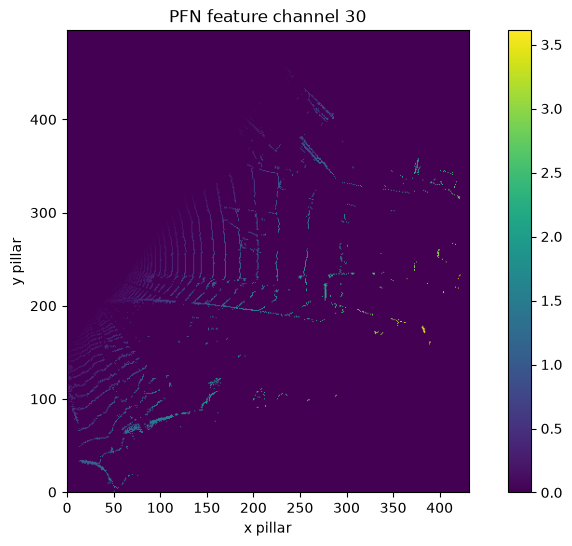

In [34]:
import matplotlib.pyplot as plt

for channel in [0, 1, 2, 3, 10, 20, 30]:

    plt.figure(figsize=(10, 6))

    plt.imshow(bev[channel].detach().cpu().numpy(), origin="lower")

    plt.title(f"PFN feature channel {channel}")
    plt.xlabel("x pillar")
    plt.ylabel("y pillar")
    plt.colorbar()

    plt.show()

__Plotting Feature Magnitudes__

In [35]:
feature_magnitude = torch.norm(bev, dim=0)
print(feature_magnitude.shape)

torch.Size([496, 432])


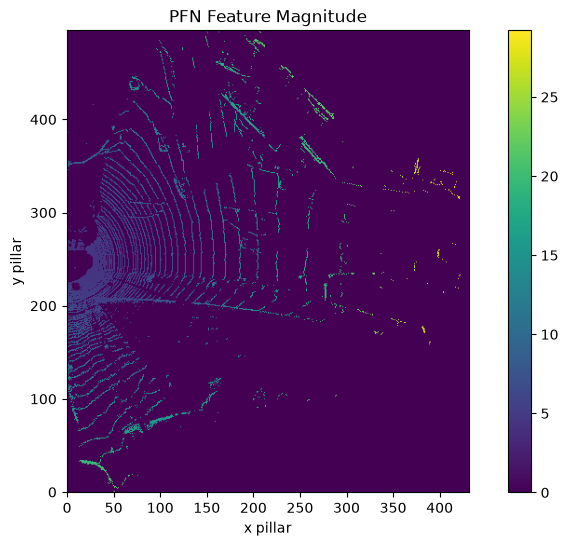

In [36]:
plt.figure(figsize=(10, 6))

plt.imshow(feature_magnitude.detach().cpu().numpy(), origin="lower")

plt.title("PFN Feature Magnitude")
plt.xlabel("x pillar")
plt.ylabel("y pillar")
plt.colorbar()

plt.show()

__CNN Backbone__

In [37]:
# Loading labels
frame.load_labels()
cars = [object for object in frame.objects if object.type == 'Car']

In [38]:
frame.load_calibration()
conv_matrix = np.linalg.inv(frame.lidar_to_cam)

In [39]:
# create targets from object labels
cls_target, reg_target, yaw_target = pillarize.object3d_to_targets(objects=cars,
                                                                   filter='Car',
                                                                   conv_matrix=conv_matrix)

In [40]:
cls_target_tensor = torch.as_tensor(cls_target, dtype=torch.float32)
reg_target_tensor = torch.as_tensor(reg_target, dtype=torch.float32)
yaw_target_tensor = torch.as_tensor(yaw_target, dtype=torch.float32)

cls_target_tensor = cls_target_tensor.unsqueeze(0).unsqueeze(0)
reg_target_tensor = reg_target_tensor.unsqueeze(0)
yaw_target_tensor = yaw_target_tensor.unsqueeze(0)

In [41]:
print(cls_target_tensor.shape,
      reg_target_tensor.shape,
      yaw_target_tensor.shape)


torch.Size([1, 1, 496, 432]) torch.Size([1, 6, 496, 432]) torch.Size([1, 2, 496, 432])


In [42]:
model = PointPillars().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

pillars_tensor = pillars_tensor.to(device)
cls_target_tensor = cls_target_tensor.to(device)
reg_target_tensor = reg_target_tensor.to(device)
yaw_target_tensor = yaw_target_tensor.to(device)

for epoch in range(500):

	model.train()
	cls_pred, reg_pred, yaw_pred = model(pillars_tensor,
                                         non_empty_coords,
                                         pillarize)

	loss, losses = detection_loss(cls_pred,
                                  reg_pred,
                                  yaw_pred,
                                  cls_target_tensor,
                                  reg_target_tensor,
                                  yaw_target_tensor)

	optimizer.zero_grad()
	loss.backward()
	optimizer.step()

	if epoch % 10 == 0:
		print(
        	f"Epoch {epoch:03d} | "
        	f"total={losses['total'].item():.4f} | "
        	f"cls={losses['cls'].item():.4f} | "
        	f"reg={losses['reg'].item():.4f} | "
        	f"yaw={losses['yaw'].item():.4f}"
		)

Epoch 000 | total=8.9552 | cls=0.6560 | reg=7.9875 | yaw=0.3117
Epoch 010 | total=5.7306 | cls=0.4111 | reg=5.2632 | yaw=0.0564
Epoch 020 | total=3.8572 | cls=0.3058 | reg=3.4879 | yaw=0.0636
Epoch 030 | total=2.6750 | cls=0.2214 | reg=2.4477 | yaw=0.0059


KeyboardInterrupt: 